In [1]:
import matplotlib as mpl
from scipy.optimize import minimize
%matplotlib inline
# Set the font to Times New Roman or a similar serif font
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = 'Times New Roman'
# Adjust the text sizes
mpl.rcParams['axes.labelsize'] = 10  # For X and Y axis labels
mpl.rcParams['axes.titlesize'] = 10  # For the plot title
mpl.rcParams['legend.fontsize'] = 10 # For the legend


from utils import *


Processing through tlist: 100%|██████████| 474/474 [00:01<00:00, 334.17it/s]
 /var/folders/yv/8f1w22v95lj4r3b_62lwrtvr0000gn/T/ipykernel_85693/710360827.py: 76

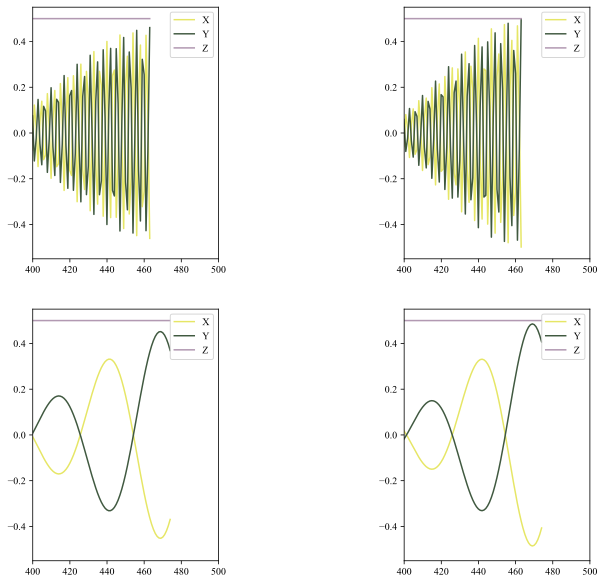

In [13]:
# with open(f'pickles/mesolve_reference_states_{0}{0}_(infidelity,phase).pkl', 'rb') as file:
#     (_,phase_01_1em3) = pickle.load(file)

# with open(f'pickles/mesolve_reference_states_{1}{0}_(infidelity,phase).pkl', 'rb') as file:
#     (_,phase_12_1em3) = pickle.load(file)

# with open(f'pickles/sesolve_reference_states_{0}{0}_(infidelity,phase).pkl', 'rb') as file:
#     (_,phase_01_0) = pickle.load(file)

# with open(f'pickles/sesolve_reference_states_{1}{0}_(infidelity,phase).pkl', 'rb') as file:
#     (_,phase_12_0) = pickle.load(file)


# phases = [
#     [phase_01_1em3,phase_01_0],
#     [phase_12_1em3,phase_12_0]
# ]
zero = qutip.basis(2, 0)
one = qutip.basis(2, 1)



Paulis = [qutip.sigmax(),qutip.sigmay(),qutip.sigmaz()]
    
colors = [(0.9, 0.9, 0.4), (0.5*0.5, 0.7*0.5, 0.5*0.5), (0.7, 0.6, 0.7)]
linestyles = [(0,(3,1,1,1)),'-',(0,(5,2,5,2))]
fig = plt.figure(figsize=(10,10))
gs = gridspec.GridSpec(2,2, width_ratios=[1,1], height_ratios=[1,1],wspace=1.0,hspace=0.2)



# two rows for different qubit
for i, filename in enumerate([
            'pickles/mesolve_01_pauli_dm.pkl',
            'pickles/mesolve_12_pauli_dm.pkl'
        ]):
    with open(filename, 'rb') as file:
        results_combined = pickle.load(file)
    num_time_steps = len(results_combined[0].times)

    # different kappa will be plotted in the same subplots
    for j, (kappa, results) in enumerate(zip([1e-3,0],[results_combined[0:4],results_combined[4:]])):
        errors = {
            'X': [],
            'Y': [],
            'Z': []
        }
        for idx in tqdm(range(num_time_steps), desc='Processing through tlist'):
            dms = [results[0].states[idx],
                      results[1].states[idx],
                      results[2].states[idx],
                      results[3].states[idx]]
            # gate = qutip.qip.operations.phasegate(phases[i][j][idx])
            gate = qutip.qip.operations.phasegate()
            for P, Pauli in zip(['X','Y','Z'],Paulis):
                inner_product_vals = []
                for a,b, dm in zip(
                    [zero,zero,one,one],
                    [zero,one,zero,one],
                    [dms[0],dms[1],dms[2],dms[3]]
                    ):
                    the_second_term = Pauli * a * b.dag() * Pauli.dag()                    
                    dm = gate * dm * gate.dag()
                    inner_product = (the_second_term * dm).tr()
                    inner_product_vals.append(inner_product)
                # print(inner_product_vals)
                errors[P].append(sum(inner_product_vals)/len(inner_product_vals))

        ax = plt.subplot(gs[i,j])
        ax.plot(results[0].times,errors['X'],label = 'X',color = colors[0])
        ax.plot(results[0].times,errors['Y'],label = 'Y',color = colors[1])
        ax.plot(results[0].times,errors['Z'],label = 'Z',color = colors[2])
        
        # ax.set_yscale('log')
        ax.legend()
        ax.set_xlim((400,500))
fig.tight_layout()  
plt.show()